# hysteresis curve of a small particle

### anisotropy energy density and Zeeman energy
 
$E_\mathrm{ani} =      K \sin^2(\varphi) V$

$E_\mathrm{zee} = - H J_\mathrm{s} \cos(\theta-\varphi) V$, $J_\mathrm{s} = \mu_0 M_\mathrm{s}$

### normalize energies: divide by $2KV$

$e_\mathrm{ani} =      \frac{1}{2} \sin^2(\varphi)$

$e_\mathrm{zee} = - h \cos(\theta-\varphi)$, with $h = H \frac{J_\mathrm{s}}{2K}$ 

In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 12})

import numpy as np
from scipy.optimize import minimize

### energy density

In [2]:
def energy_density(phi, h, theta):
  e_ani = 0.5*(np.sin(phi))**2
  e_zee = - h*np.cos(theta-phi)
  return (e_ani + e_zee).squeeze()

### hysteresis loop

In [3]:
h_values = np.concatenate( (np.linspace( 1.2,-1.2,100),   # down
                            np.linspace(-1.2, 1.2,100)) ) # up
                          
theta = np.radians(10.0) # field angle
phi = theta              # initial magnetization angle

mh = []
for h in h_values:
  res = minimize(energy_density,phi,args=(h,theta))
  phi = res.x[0]
  mh.append(np.cos(phi-theta).squeeze())

### plot

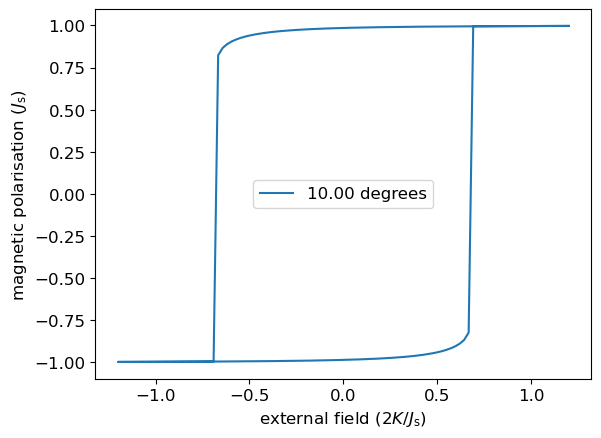

In [4]:
plt.plot(h_values,mh,label=f'{np.degrees(theta):.2f} degrees')
plt.xlabel(r'external field $(2K/J_\mathrm{s})$')
plt.ylabel(r'magnetic polarisation $(J_\mathrm{s})$')
plt.legend()